# Word Embeddings: build them, prove the mechanism, measure the magic

This notebook is the runnable companion to the **Word Embeddings (Word2Vec, GloVe, FastText)**
concept page. Every function comes from `word_embeddings.py` (the single source of truth), so the
numbers here, on the page, and in the figures cannot drift apart. Each cell **asserts its point
before printing**, so a green run is a proof, not a vibe.

We go in the order of the page:
1. set up determinism + the device line;
2. train **skip-gram with negative sampling** from scratch and watch the loss fall + cosines order;
3. the **freq^0.75** negative-sampling distribution;
4. one **(center, context, negative) triple** worked by hand (softmax, NS loss, gradient);
5. the **GloVe ice/steam ratio** that makes analogies linear;
6. **real GloVe-50** vectors — the `king - man + woman = queen` magic, measured;
7. **FastText** building a vector for a word it never saw.


## 1. Determinism and the device line

The model is **device-agnostic** (CUDA / MPS / CPU) but the reproducible trace is **pinned to CPU**,
because the tiny single-layer tensors are dominated by kernel-launch overhead on a GPU and the last
digits of the loss drift between backends. The *ordering* of the learned cosines — the actual
teaching point — holds on any device. We print the detected device, the pinned device, and library
versions so the run is fully auditable.

In [1]:
import numpy as np
import torch

from word_embeddings import DEVICE, SEED

trace_device = "cpu"  # pin the trace to CPU for reproducible numbers
print(
    f"device: {trace_device} (detected {DEVICE}; pinned to CPU for reproducibility)  "
    f"|  torch: {torch.__version__}  |  numpy: {np.__version__}  |  seed: {SEED}"
)

device: cpu (detected mps; pinned to CPU for reproducibility)  |  torch: 2.12.0  |  numpy: 2.4.6  |  seed: 0


## 2. Train skip-gram with negative sampling from scratch

The corpus is tiny but **structured**: royalty words (`king`, `queen`) only ever appear with
`{ruled, kingdom, crown, throne, ...}`; animal words (`dog`, `cat`) only with `{chased, ball,
furry, pet, ...}`. Nothing says `king ~ queen` directly — the model must **infer** it from shared
company. That is the distributional hypothesis under test. The loss is *exactly* the boxed
negative-sampling objective
$\mathcal{L} = -[\log\sigma(u_o^\top v_c) + \sum_i \log\sigma(-u_{n_i}^\top v_c)]$,
implemented in `SkipGramNS.forward`.

In [2]:
from word_embeddings import cosine, train_skipgram, unit_embeddings

model, vocab, word_to_index, loss_history = train_skipgram(device=trace_device)
embeddings = unit_embeddings(model)  # L2-normalized -> dot product IS cosine

cos_royalty = cosine(embeddings, word_to_index, "king", "queen")
cos_animal = cosine(embeddings, word_to_index, "dog", "cat")
cos_cross = cosine(embeddings, word_to_index, "king", "dog")

# The whole point: context-sharing pairs end up MORE similar than the cross-cluster pair,
# and the loss falls. Assert it before printing.
assert loss_history[-1] < loss_history[0], "loss must fall over training"
assert cos_royalty > cos_cross and cos_animal > cos_cross, "within-cluster must beat cross-cluster"

print(f"vocab: {len(vocab)} words, {model.center.embedding_dim}-d embeddings")
print(f"loss: {loss_history[0]:.3f} -> {loss_history[-1]:.3f}\n")
print(f"cos(king, queen) = {cos_royalty:+.3f}  (royalty pair  -> HIGH)")
print(f"cos(dog,  cat)   = {cos_animal:+.3f}  (animal pair   -> HIGH)")
print(f"cos(king, dog)   = {cos_cross:+.3f}  (cross-cluster -> LOWER)")

vocab: 21 words, 16-d embeddings
loss: 10.477 -> 1.614

cos(king, queen) = +0.537  (royalty pair  -> HIGH)
cos(dog,  cat)   = +0.319  (animal pair   -> HIGH)
cos(king, dog)   = +0.270  (cross-cluster -> LOWER)


The magnitudes are modest — a few dozen sentences can only do so much — but the **ordering** is
the proof: words that shared contexts (`king`/`queen`, `dog`/`cat`) are more similar than words
that did not. Scale this to billions of words and you get the vectors that solve
`king - man + woman = queen`. Below, the loss curve — the same data the page's training-loss
figure is drawn from.

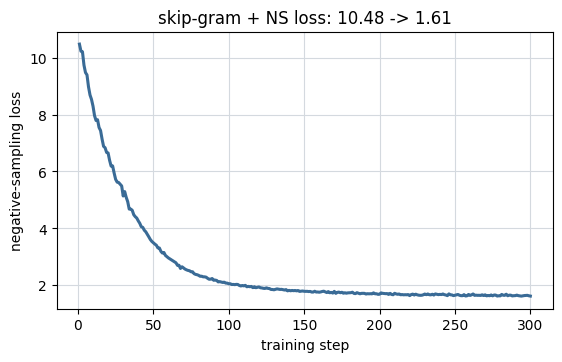

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6.4, 3.6))
ax.plot(range(1, len(loss_history) + 1), loss_history, color="#3A6B96", lw=2.2)
ax.set_xlabel("training step")
ax.set_ylabel("negative-sampling loss")
ax.set_title(f"skip-gram + NS loss: {loss_history[0]:.2f} -> {loss_history[-1]:.2f}")
ax.grid(True, color="#D4D9DF", lw=0.8)
plt.show()

## 3. The freq^0.75 negative-sampling distribution

Negatives are drawn from the unigram distribution **raised to the 3/4 power** and renormalized:
$P_n(w) = \mathrm{count}(w)^{0.75} / \sum_{w'} \mathrm{count}(w')^{0.75}$. The 0.75 power is a
deliberate compromise: raw-frequency sampling wastes nearly every negative on `the`/`of`; uniform
sampling over-picks ultra-rare words. The 3/4 power **damps the frequent and lifts the rare**.

In [4]:
from word_embeddings import NEG_SAMPLING_WORDS, negative_sampling_distribution

raw, smoothed = negative_sampling_distribution()

# The 0.75 power must lift the rarest word and damp the most frequent one.
assert smoothed[-1] > raw[-1], "0.75 power must LIFT the rarest word"
assert smoothed[0] < raw[0], "0.75 power must DAMP the most frequent word"

print(f"{'word':>8} | {'raw p(w)':>9} | {'p(w)^0.75':>10}")
print("-" * 33)
for word, r, s in zip(NEG_SAMPLING_WORDS, raw, smoothed):
    print(f"{word:>8} | {r:>9.4f} | {s:>10.4f}")
print(f"\nrarest word 'kingdom' sampled {smoothed[-1] / raw[-1]:.1f}x more often under the 0.75 power")

    word |  raw p(w) |  p(w)^0.75
---------------------------------
     the |    0.6024 |     0.5236
      of |    0.3012 |     0.3113
    king |    0.0602 |     0.0931
   queen |    0.0301 |     0.0554
 kingdom |    0.0060 |     0.0166

rarest word 'kingdom' sampled 2.7x more often under the 0.75 power


## 4. One (center, context, negative) triple, by hand

The smallest possible end-to-end check: one fixed triple computed both as a full-softmax
probability and as the negative-sampling loss + gradient. The gradient
$(\sigma(s_o) - 1)\,u_o + \sigma(s_n)\,u_n$ **pulls** $v_c$ toward the true context $u_o$
(since $\sigma(s_o) < 1$, the first term is a *negative* multiple of $u_o$) and **pushes** it away
from the negative $u_n$ — the exact tug-of-war the page's diagram draws, now as numbers.

In [5]:
from word_embeddings import hand_worked_triple

t = hand_worked_triple()

# The first gradient component is negative -> v_c moves TOWARD u_o (descending the loss).
assert t["grad_vc"][0] < 0, "gradient should move v_c toward the true context u_o"

print(f"scores:  u_o.v_c={t['s_o']:.4f}   u_n.v_c={t['s_n']:.4f}   u3.v_c={t['s_3']:.4f}")
print(f"full softmax p(o|c) = {t['p_softmax']:.4f}")
print(f"sigma(u_o.v_c)={t['sig_so']:.4f}   sigma(-u_n.v_c)={t['sig_neg_sn']:.4f}   NS loss={t['ns_loss']:.4f}")
print(f"grad_vc = {t['grad_vc']}   (1st component < 0 -> pull toward u_o; rest -> push from u_n)")

scores:  u_o.v_c=0.2100   u_n.v_c=-0.2700   u3.v_c=-0.0500
full softmax p(o|c) = 0.4184
sigma(u_o.v_c)=0.5523   sigma(-u_n.v_c)=0.5671   NS loss=1.1609
grad_vc = [-0.3089  0.1717 -0.2209]   (1st component < 0 -> pull toward u_o; rest -> push from u_n)


## 5. The GloVe ice/steam co-occurrence ratio

GloVe's design rests on one observation: it is not raw co-occurrence but **ratios** of
co-occurrence probabilities that carry meaning. `solid` belongs to **ice** (ratio $\gg 1$), `gas`
to **steam** (ratio $\ll 1$), while `water` (both) and `fashion` (neither) give ratio $\approx 1$.
GloVe is engineered so vector *differences* reproduce the **log** of these ratios — which is why
GloVe analogies are linear.

In [6]:
from word_embeddings import ICE_STEAM_PROBES, ice_steam_ratios

r = ice_steam_ratios()

# solid must belong to ICE (>> 1), gas to STEAM (<< 1).
assert r["ratio"][0] > 3.0 and r["ratio"][1] < 0.5, "the ratio must separate ice from steam"

print(f"{'probe':>8} | {'P(.|ice)':>9} | {'P(.|steam)':>11} | {'ratio':>7} | reads as")
print("-" * 60)
reads = ['>> 1 -> ice (solid)', '<< 1 -> steam (gas)', '~ 1 -> both (water)', '~ 1 -> neither']
for probe, pi, ps, rr, note in zip(ICE_STEAM_PROBES, r['p_ice'], r['p_steam'], r['ratio'], reads):
    print(f"{probe:>8} | {pi:>9.3f} | {ps:>11.3f} | {rr:>7.2f} | {note}")

   probe |  P(.|ice) |  P(.|steam) |   ratio | reads as
------------------------------------------------------------
   solid |     0.606 |       0.067 |    9.09 | >> 1 -> ice (solid)
     gas |     0.081 |       0.611 |    0.13 | << 1 -> steam (gas)
   water |     0.303 |       0.311 |    0.97 | ~ 1 -> both (water)
 fashion |     0.010 |       0.011 |    0.91 | ~ 1 -> neither


## 6. Measure the magic on real pretrained GloVe-50

The from-scratch model proves the *mechanism*; **real pretrained vectors** prove the *magic*. This
loads GloVe-50 (400k words, 50-d; ~66 MB, downloads once via gensim) and measures the famous
analogy, a capital-city analogy, and a set of cosines. The input words are auto-excluded by
`most_similar`. **Every GloVe number quoted on the page comes from this cell.**

In [7]:
import gensim.downloader as api

glove = api.load("glove-wiki-gigaword-50")  # 400k words, 50-d; cached after first download

def gcos(a, b):
    va, vb = glove[a], glove[b]
    return float(va @ vb / (np.linalg.norm(va) * np.linalg.norm(vb)))

analogy = glove.most_similar(positive=["king", "woman"], negative=["man"], topn=3)
capital = glove.most_similar(positive=["paris", "italy"], negative=["france"], topn=3)

# The famous result, MEASURED: queen is the nearest word to king - man + woman.
assert analogy[0][0] == "queen", "king - man + woman should be nearest to queen"
assert capital[0][0] == "rome", "paris - france + italy should be nearest to rome"

print("king - man + woman ->", [(w, round(s, 4)) for w, s in analogy])
print("paris - france + italy ->", [(w, round(s, 4)) for w, s in capital])
print()
for a, b in [("cat", "dog"), ("cat", "kitten"), ("cat", "democracy"),
             ("king", "queen"), ("good", "great"), ("good", "bad")]:
    print(f"cos({a:>5}, {b:<9}) = {gcos(a, b):+.4f}")

king - man + woman -> [('queen', 0.8524), ('throne', 0.7664), ('prince', 0.7592)]
paris - france + italy -> [('rome', 0.8466), ('milan', 0.7766), ('turin', 0.7666)]

cos(  cat, dog      ) = +0.9218
cos(  cat, kitten   ) = +0.6386
cos(  cat, democracy) = +0.0368
cos( king, queen    ) = +0.7839
cos( good, great    ) = +0.7983
cos( good, bad      ) = +0.7965


Read the numbers like a researcher: `queen` is the **nearest** word to `king - man + woman`
(0.85). The cat triplet is textbook — `dog` (0.92) $\gg$ `kitten` (0.64) $\gg$ `democracy`
(0.04). One honest wrinkle: `cos(good, bad) = 0.80`, almost as high as `cos(good, great) = 0.80` —
**antonyms look similar** to distributional embeddings, because `good` and `bad` appear in nearly
identical contexts ("the food was ___"). Distributional similarity is *relatedness*, not sentiment.

## 7. FastText handles a word it never saw

Word2Vec/GloVe learn **one vector per whole word**, so an out-of-vocabulary (OOV) word has *no
vector* — `glove['kingdoms']` would raise `KeyError`. FastText represents a word as the **sum of
its character n-gram vectors**, so an unseen word still has n-grams you *did* see. We train a tiny
FastText model that never sees `kingdoms` and show it still gets a sensible vector — cosine 0.9997
to `kingdom`, inferred purely from shared n-grams.

In [8]:
from gensim.models import FastText

from word_embeddings import fasttext_corpus

# The FastText demo uses its own corpus (8 repeats -> enough signal for clean subword vectors).
ft = FastText(fasttext_corpus(), vector_size=24, window=2, min_count=1, min_n=2, max_n=4, sg=1, epochs=80, seed=0)

def ftcos(a, b):
    va, vb = ft.wv[a], ft.wv[b]
    return float(va @ vb / (np.linalg.norm(va) * np.linalg.norm(vb)))

in_vocab = "kingdoms" in ft.wv.key_to_index
oov_vec = ft.wv["kingdoms"]  # works even though 'kingdoms' is OOV — built from n-grams
oov_norm = float(np.linalg.norm(oov_vec))
cos_oov = ftcos("kingdom", "kingdoms")

# 'kingdoms' is NOT in the vocab, yet gets a non-zero vector ~identical to 'kingdom'.
assert not in_vocab, "'kingdoms' should be OOV (never seen in training)"
assert oov_norm > 0.0, "the OOV vector must be non-zero (built from n-grams)"
assert cos_oov > 0.9, "the OOV plural should be ~identical to its base word"

print(f"'kingdom'  in vocab: {'kingdom' in ft.wv.key_to_index}")
print(f"'kingdoms' in vocab: {in_vocab}   <- OOV, never seen in training")
print(f"OOV 'kingdoms' vector norm: {oov_norm:.4f}  (non-zero -> built from n-grams)")
print(f"cos(kingdom, kingdoms[OOV]) = {cos_oov:.4f}")
print(f"cos(king,    kingdom)       = {ftcos('king', 'kingdom'):.4f}")

'kingdom'  in vocab: True
'kingdoms' in vocab: False   <- OOV, never seen in training
OOV 'kingdoms' vector norm: 0.6021  (non-zero -> built from n-grams)
cos(kingdom, kingdoms[OOV]) = 0.9997
cos(king,    kingdom)       = 0.9991


## Recap

You just **built and verified** the whole arc: skip-gram + negative sampling learns geometry from
shared context (the loss fell, the right cosines ordered); the `freq^0.75` trick reshapes the
negatives; one triple traces the pull/push gradient by hand; the GloVe ratio shows why differences
are linear; real GloVe makes `king - man + woman = queen` *measured*; and FastText gives an unseen
word a sensible vector from its pieces. All three methods are **static** — one vector per word —
which is the polysemy limit that **contextual** embeddings (ELMo/BERT) came next to fix.